In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
#imports + load data
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Regression Datasets (1)/wk07-regression/homeprices.csv')
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [92]:
!ls

areas.csv	homeprices-m.csv	 prediction.csv
homeprices.csv	linear_regression.ipynb


In [93]:
#Explore Dataset
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


,0
area,0
price,0


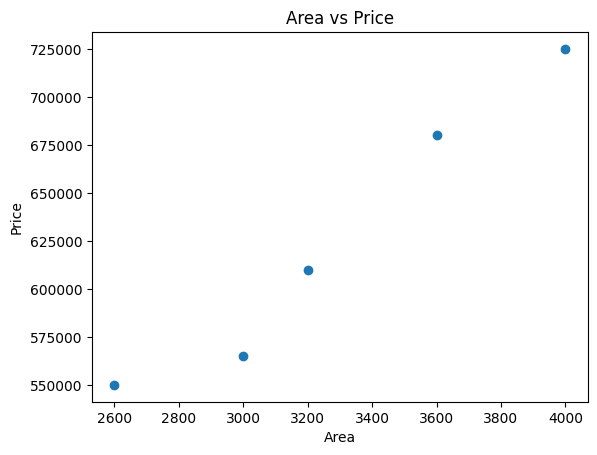

In [94]:
#visualize dataset
plt.scatter(df['area'], df['price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

In [95]:
#prepare data
from sklearn.model_selection import train_test_split

X = df[['area']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [96]:
#Train model
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [97]:
#Evaluate model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 31355.140186915873
MSE: 983144816.1411468
RMSE: 31355.140186915873
R² Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


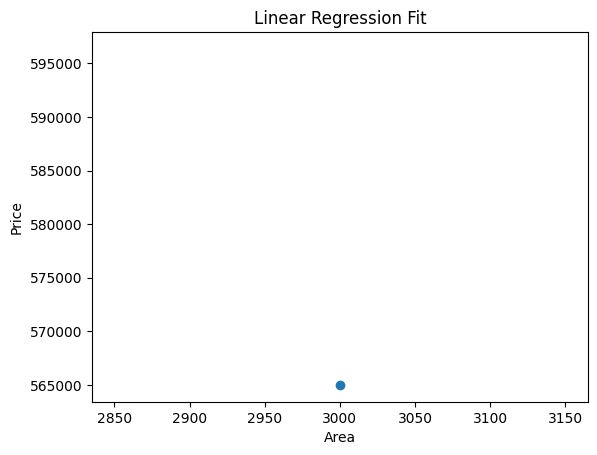

In [98]:
#plotted regression line
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Linear Regression Fit')
plt.show()